<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


### Install the required libraries.


In [42]:
!pip install pandas

In [43]:
!pip install matplotlib

In [64]:
!pip install numpy

In [65]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Download the Dataset

In [122]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv')
df

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11393,25136,I am a developer by profession,Yes,Never,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Cour...,36.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Difficult
11394,25137,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,Poland,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,A lot more welcome now than last year,Tech articles written by other developers;Tech...,25.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
11395,25138,I am a developer by profession,Yes,Less than once per year,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,A lot more welcome now than last year,Tech articles written by other developers;Indu...,34.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Too long,Easy
11396,25141,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of LOWER quality than prop...",Employed full-time,Switzerland,No,"Secondary school (e.g. American high school, G...",NaN,...,Somewhat less wel

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [49]:
data = df['CompTotal'].dropna()
print('There are', data.value_counts().shape[0] , 'different values in the CompTotal column.')

There are 1509 different values in the CompTotal column.


In [12]:
"""
Because we have many different values we will group them in 4 sections.
Each section will be a quantile.
We will exclude outliers.
"""

'\nBecause we have many different values we will group them in 4 sections.\nEach section will be a quantile.\nWe will exclude outliers.\n'

In [53]:
# Quartiles
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

# IQR
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)

Q1: 25000.0
Q3: 120000.0
IQR: 95000.0


In [57]:
# In this case we will accept any total compensation up to 262500. If we wanted to keep higher compensations in the analysis we would simply modify the upper bound.

In [58]:
# Define bounds
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: 0
Upper Bound: 262500.0


In [59]:
outliers = data[(data < lower_bound) | (data > upper_bound)]

In [60]:
print('Number of outliers:', len(outliers))

Number of outliers: 1120


In [61]:
# We will drop the outliers from our data, so that they are excluded from the analysis
clean_data = data[(data >= lower_bound) & (data <= upper_bound)]

In [62]:
print("Original size:", len(data))
print("Cleaned size:", len(clean_data))
print("Removed outliers:", len(data) - len(clean_data))
print("After handling outliers, the new number of different values in the CompTotal is:", clean_data.value_counts().shape[0])

Original size: 10589
Cleaned size: 9469
Removed outliers: 1120
After handling outliers, the new number of different values in the CompTotal is: 1163


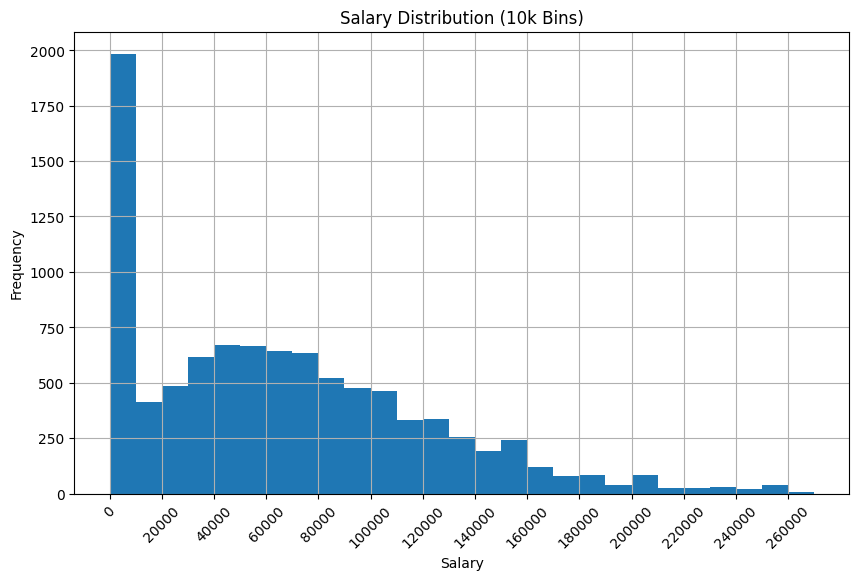

In [66]:
# Histogram
bin_width = 10000
bins = np.arange(0, 280000, bin_width)

plt.figure(figsize=(10, 6))
plt.hist(clean_data, bins=bins)

plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution (10k Bins)')
plt.xticks(bins[::2], rotation=45)
plt.grid(True)

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [67]:
ycp_df = df['YearsCodePro'].dropna()

In [71]:
# ycp_df appears as an object data type
ycp_df.dtype

dtype('O')

In [68]:
ycp_df.value_counts()

YearsCodePro
3                   1287
2                   1216
4                   1058
5                   1057
6                    754
1                    670
10                   667
7                    600
8                    567
Less than 1 year     486
12                   337
9                    322
15                   299
11                   291
20                   269
13                   226
14                   193
18                   165
16                   123
19                   109
22                    97
17                    83
21                    81
25                    76
23                    62
30                    58
24                    45
28                    28
26                    22
27                    21
32                    20
33                    18
35                    17
31                    13
29                    10
34                     7
40                     5
38                     5
36                     4
37          

In [69]:
# We see that there is a str value 'Less than 1 year' we need to conver this and all values to numeric.

In [70]:
ycp_df = ycp_df.replace('Less than 1 year', 0.5)

In [72]:
ycp_df = pd.to_numeric(ycp_df)

In [76]:
print(ycp_df.dtype)

float64


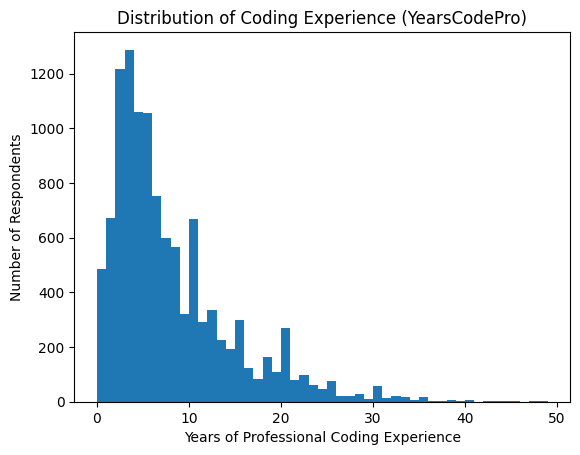

In [81]:
plt.figure()
bin_width = 1
bins = np.arange(0,50, bin_width)
plt.hist(ycp_df, bins=bins)

plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Coding Experience (YearsCodePro)')

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [ ]:
# Previously we found that the upper bound for CompTotal is 263000.
# So we will only include rows that have CompTotal values less than 263000.

In [136]:
cta_df = df[['CompTotal','Age']]

In [138]:
cta_df.dropna()

,CompTotal,Age,AgeGroup
0,61000.0,22.0,20-30
1,138000.0,23.0,20-30
2,90000.0,28.0,20-30
3,29000.0,26.0,20-30
4,90000.0,29.0,20-30
...,...,...,...
11392,800.0,32.0,30-40
11393,130000.0,36.0,30-40
11394,74400.0,25.0,20-30
11395,105000.0,34.0,30-40


In [139]:
cta_df = cta_df[cta_df['CompTotal'] < 300000]

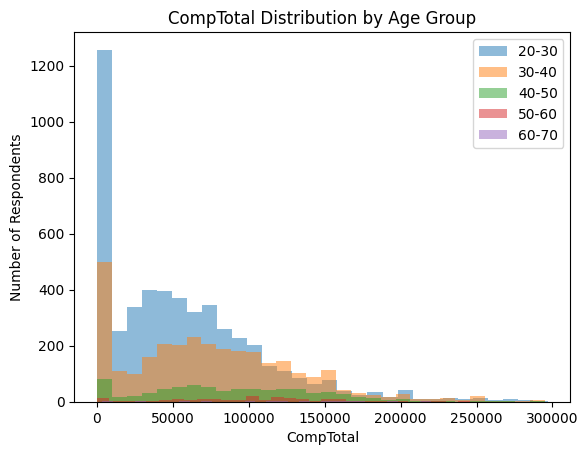

In [140]:
# Create age groups (bins)
cta_df['AgeGroup'] = pd.cut(
    cta_df['Age'],
    bins=[20, 30, 40, 50, 60, 70],
    labels=['20-30', '30-40', '40-50', '50-60', '60-70']
)

# Plot histograms for each age group
plt.figure()

for group in cta_df['AgeGroup'].dropna().unique():
    subset = cta_df[cta_df['AgeGroup'] == group]['CompTotal']
    plt.hist(subset, bins=30, alpha=0.5, label=str(group))

plt.xlabel('CompTotal')
plt.ylabel('Number of Respondents')
plt.title('CompTotal Distribution by Age Group')
plt.legend()

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [146]:
df['DatabaseDesireNextYear'].dropna()

0                                             MySQL;SQLite
1                                  PostgreSQL;Redis;SQLite
2                                     Firebase;MySQL;Redis
3        Elasticsearch;MongoDB;Microsoft SQL Server;SQLite
4                Elasticsearch;Firebase;MongoDB;PostgreSQL
                               ...                        
11392            Couchbase;Firebase;MariaDB;MongoDB;Oracle
11393                                 Microsoft SQL Server
11394                                MariaDB;MongoDB;MySQL
11396     Elasticsearch;MongoDB;Microsoft SQL Server;Redis
11397                                           PostgreSQL
Name: DatabaseDesireNextYear, Length: 10356, dtype: str

In [ ]:
# We see many answers per line, each survey participant wants to work with multiple databases
# We will split each entry and explode each database type to a new row and then count them all

In [156]:
db_series = df['DatabaseDesireNextYear'].dropna().str.split(';').explode()

top5_db = db_series.value_counts().head()

In [157]:
top5_db

DatabaseDesireNextYear
PostgreSQL       4328
MongoDB          3649
Redis            3331
MySQL            3281
Elasticsearch    2856
Name: count, dtype: int64

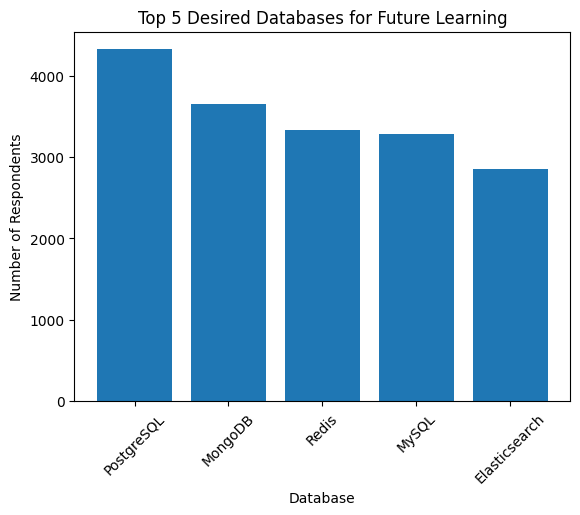

In [158]:
plt.figure()
plt.bar(top5_db.index, top5_db.values)

plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.title('Top 5 Desired Databases for Future Learning')

plt.xticks(rotation=45)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [164]:
work_remote_df = df['WorkRemote'].dropna()
work_remote_df = work_remote_df.value_counts()
work_remote_df

WorkRemote
Less than once per month / Never                           5100
A few days each month                                      3213
Less than half the time, but at least one day each week    1097
All or almost all the time (I'm full-time remote)           961
It's complicated                                            461
More than half, but not all, the time                       299
About half the time                                         259
Name: count, dtype: int64

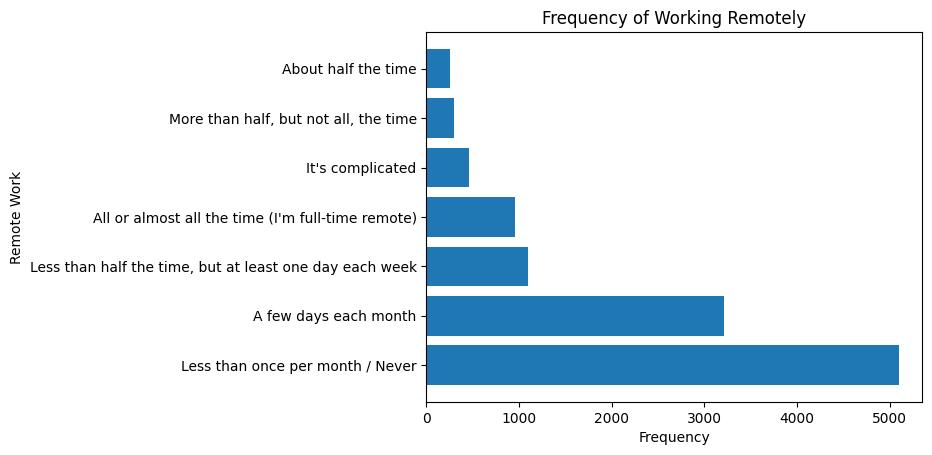

In [169]:
plt.figure()
plt.barh(work_remote_df.index, work_remote_df.values)

plt.xlabel('Frequency')
plt.ylabel('Remote Work')
plt.title('Frequency of Working Remotely')

plt.xticks()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Text(0.5, 1.0, 'Compensation Distribution (Age 45–60)')

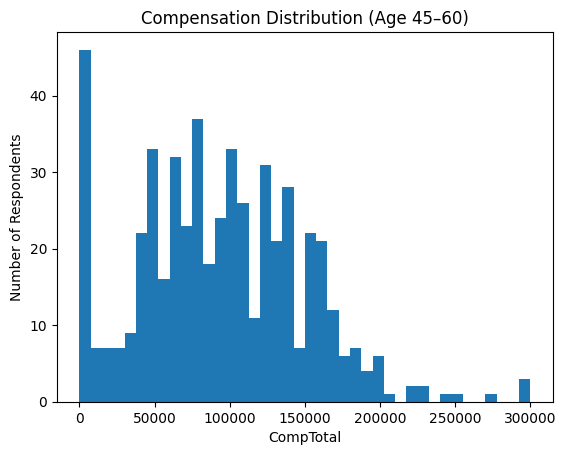

In [175]:
filtered = df[(df['Age'] >= 45) & (df['Age'] <= 60)]
filtered = filtered[(filtered['CompTotal'] >= 0) & (filtered['CompTotal'] <= 300000)]

# I will drop the missing compensation values
comp = filtered['CompTotal'].dropna()

# Plot histogram
plt.figure()
plt.hist(comp, bins=40)

plt.xlabel('CompTotal')
plt.ylabel('Number of Respondents')
plt.title('Compensation Distribution (Age 45–60)')

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


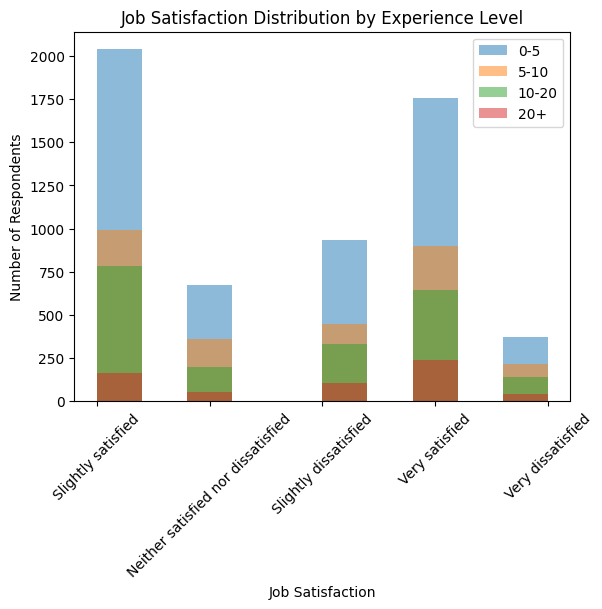

In [177]:
# Select and clean data
js_df = df[['JobSat', 'YearsCodePro']].dropna()

# We will onvert YearsCodePro to numeric
js_df['YearsCodePro'] = js_df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
})
js_df['YearsCodePro'] = pd.to_numeric(js_df['YearsCodePro'], errors='coerce')

# Create the experience groups
js_df['ExpGroup'] = pd.cut(
    js_df['YearsCodePro'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5', '5-10', '10-20', '20+']
)

# Plot histograms for each experience group
plt.figure()

for group in js_df['ExpGroup'].dropna().unique():
    subset = js_df[js_df['ExpGroup'] == group]['JobSat']
    plt.hist(subset, bins=10, alpha=0.5, label=str(group))

plt.xlabel('Job Satisfaction')
plt.ylabel('Number of Respondents')
plt.title('Job Satisfaction Distribution by Experience Level')
plt.legend()

plt.xticks(rotation=45)

plt.show()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
